## DRAGONS API reduction of G-2025G-0505-V NGC6744 dwarf galaxy candidates

In [1]:
import glob
import os

In [2]:
import astrodata
import gemini_instruments
from recipe_system.reduction.coreReduce import Reduce
from gempy.adlibrary import dataselect

In [3]:
from gempy.utils import logutils

In [72]:
from dragonslib import drdisplay, reduce, specplot, sensfunc_plot

In [5]:
import nest_asyncio
nest_asyncio.apply()

In [6]:
# Set paths
root_dir = os.path.join(os.environ['HOME'], 'research', 'neighborhood_watch', 'G-2025B-0505-V')
print(root_dir)
raw_path = os.path.join(root_dir, 'raw')
proc_path = os.path.join(root_dir, 'dragons_v2')
print(raw_path)
print(proc_path)

/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/dragons_v2


In [7]:
if not os.access(proc_path, os.W_OK):
    print(f"{proc_path} does not exist, creating")
    os.mkdir(proc_path)

In [8]:
# calibration service
from recipe_system import cal_service

# caldb = cal_service.set_local_database()
# caldb.init()

caldb = cal_service.LocalDB(os.path.join(proc_path, 'g25B_0505v_calib.db'))
caldb.init()

In [9]:
for f in caldb.list_files():
    print(f)

In [10]:
logutils.config(file_name=os.path.join(proc_path,'g25B_0505v.log'))

In [11]:
# get file list
all_files = glob.glob(raw_path + '/*.fits')
all_files.sort()

In [12]:
for file in all_files:
    print(file)

/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250923S0043.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250923S0044.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250923S0045.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250923S0046.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250923S0047.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250925S0045.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250925S0048.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250925S0049.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250925S0050.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250926S0077.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250926S0078.fits
/Users/bryan.miller/research/neighborhood_w

In [13]:
from datetime import datetime, date

In [14]:
sep26 = date.fromisoformat('2025-09-26')
sep27 = date.fromisoformat('2025-09-27')
print(sep26)

2025-09-26


In [15]:
date_sel = dataselect.expr_parser('ut_date=="2025-9-26" or ut_date=="2025-9-27"')

In [16]:
datetime.strptime("2025-9-26", "%Y-%m-%d").date()

datetime.date(2025, 9, 26)

## Standard Reduction

In [17]:
std_biases = dataselect.select_data(all_files, ['BIAS'], [], date_sel)

In [18]:
for bias in std_biases:
    ad = astrodata.open(bias)
    print(bias, '  ', ad.detector_roi_setting(), ad.detector_x_bin(), ad.detector_y_bin())

/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250926S0077.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250926S0078.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250926S0080.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250926S0081.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250926S0082.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0153.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0154.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0156.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0157.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B

In [19]:
# Note, this picks flats for the standard, and the flat for the science on the next night, but the same UT date
std_flats = dataselect.select_data(all_files, ['FLAT'], [], dataselect.expr_parser('ut_date=="2025-9-27"'))
for flat in std_flats:
    print(flat)

/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0029.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0032.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0032.fits


In [20]:
std_arcs = dataselect.select_data(all_files, ['ARC'], [], dataselect.expr_parser('ut_date=="2025-9-27"'))
for arc in std_arcs:
    print(arc)

/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0028.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0031.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0031.fits


In [21]:
stds = dataselect.select_data(all_files, ['STANDARD'], [], dataselect.expr_parser('ut_date=="2025-9-27"'))
for std in stds:
    print(std)

/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0030.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0033.fits


In [22]:
# This just needs to be done once per bpm
for bpm in dataselect.select_data(all_files, ['BPM']):
    caldb.add_cal(bpm)

In [23]:
for f in caldb.list_files():
    print(f)

FileData(name='bpm_20231214_gmos-s_Ham_44_full_12amp.fits', path='/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw')


In [24]:
# Change to the process directory
os.chdir(proc_path)
os.getcwd()

'/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/dragons_v2'

In [25]:
# Reduce biases for standard
reduce_std_bias = Reduce()
reduce_std_bias.files.extend(std_biases)

All submitted files appear valid:
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250926S0077.fits ... /Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0158.fits, 10 files submitted.


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
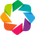

RECIPE: makeProcessedBias
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         Updating keywords that are specific to GMOS
         Updating keywords that are specific to GMOS
         Updating keywords that are specific to GMOS
         Updating keywords that are specific to GMOS
         Updating keywords that are specific to GMOS
         Updating keywords that are specific to GMOS
         Updating keywords that are specific to GMOS
         Updating keywords that are specific to GMOS
         Up

In [26]:
reduce_std_bias.runr()

In [27]:
print(reduce_std_bias.output_filenames)

['S20250926S0077_bias.fits']


In [28]:
# display = Reduce()
# display.files = ['S20250926S0077_bias.fits']
# display.recipename = 'display'
# display.runr()
drdisplay(reduce_std_bias.output_filenames[0])

All submitted files appear valid:
S20250926S0077_bias.fits
WARNING - No recipe can be found in gmos recipe libs.
WARNING - Searching primitives ...
Found 'display' as a primitive.
RECIPE: display
   PRIMITIVE: display
   ------------------
      PRIMITIVE: tileArrays
      ---------------------
      Array maps to [1:512,1:1056]
      Array maps to [528:1039,1:1056]
      Array maps to [1055:1566,1:1056]
      .
   .
reduce completed successfully.


In [34]:
# Reduce flats for standard
reduce_std_flat = Reduce()
reduce_std_flat.uparms = dict([('interactive', True)])
reduce_std_flat.files.extend(std_flats[0:2])

In [35]:
reduce_std_flat.runr()

All submitted files appear valid:
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0029.fits ... /Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0032.fits, 2 files submitted.
RECIPE: makeProcessedFlatNoStack
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         Updating keywords that are specific to GMOS
         Upda

In [36]:
print(reduce_std_flat.output_filenames)

['S20250927S0029_flat.fits', 'S20250927S0032_flat.fits']


In [37]:
# Reduce arcs for standard
reduce_std_arcs = Reduce()
reduce_std_arcs.files.extend(std_arcs[0:2])
reduce_std_arcs.uparms = dict([('interactive', True)])
reduce_std_arcs.runr()

All submitted files appear valid:
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0028.fits ... /Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0031.fits, 2 files submitted.
RECIPE: makeProcessedArc
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         Updating keywords that are specific to GMOS
         Updating key

In [38]:
drdisplay(reduce_std_arcs.output_filenames[0])

All submitted files appear valid:
S20250927S0028_arc.fits
WARNING - No recipe can be found in gmos recipe libs.
WARNING - Searching primitives ...
Found 'display' as a primitive.
RECIPE: display
   PRIMITIVE: display
   ------------------
   .
reduce completed successfully.


In [39]:
# Reduce standard
reduce_std = reduce(stds, inter=True)
# Used 5th order for trace with 4 rejection iterations
# specplot(reduce_std.output_filenames[0])

All submitted files appear valid:
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0030.fits ... /Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0033.fits, 2 files submitted.
RECIPE: reduceStandard
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         Updating keywords that are specific to GMOS
         Updating keywo

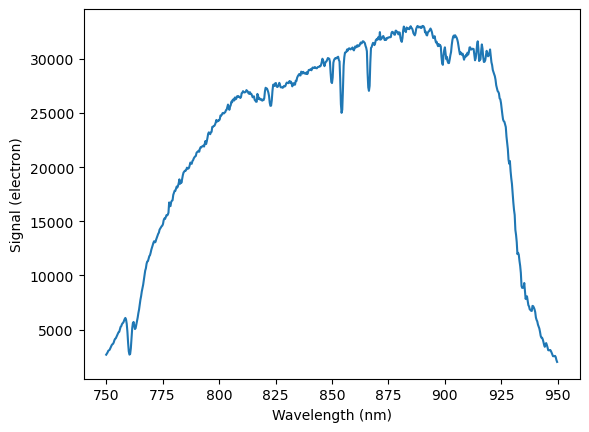

In [40]:
# Display result after processing
std_output = os.path.join(proc_path,'S20250927S0030_standard.fits')
specplot(std_output, wavelen=[750, 950])

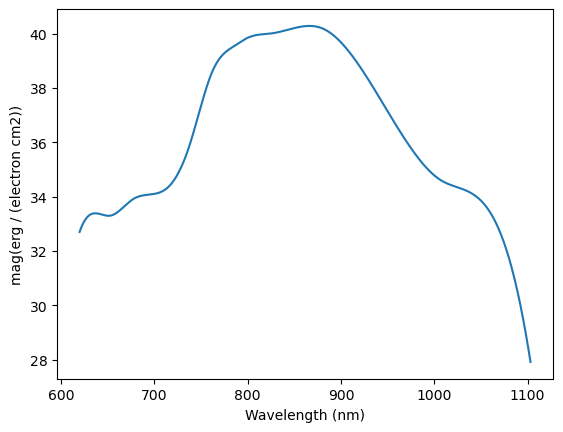

In [43]:
sensfunc_plot(std_output)

## Galaxy Reductions

In [44]:
date_sel_sci = dataselect.expr_parser('ut_date=="2025-9-27" or ut_date=="2025-9-28"')

In [45]:
sci_biases = dataselect.select_data(all_files, ['BIAS'], [], date_sel_sci)

In [46]:
for bias in sci_biases:
    ad = astrodata.open(bias)
    print(bias, '  ', ad.detector_roi_setting(), ad.detector_x_bin(), ad.detector_y_bin())

/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0153.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0154.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0156.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0157.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0158.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0125.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0126.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0128.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0129.fits    Full Frame 4 4
/Users/bryan.miller/research/neighborhood_watch/G-2025B

In [47]:
# Reduce biases for galaxies
reduce_sci_bias = reduce(sci_biases, inter=False)

All submitted files appear valid:
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250927S0153.fits ... /Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0130.fits, 10 files submitted.
RECIPE: makeProcessedBias
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         Updating keywords that are specific to GMOS
         Updating keywords that are specific to GMOS
         Updating keywords that are specific to GMOS
         Updating keywords that are specifi

In [48]:
drdisplay(reduce_sci_bias.output_filenames[0])

All submitted files appear valid:
S20250927S0153_bias.fits
WARNING - No recipe can be found in gmos recipe libs.
WARNING - Searching primitives ...
Found 'display' as a primitive.
RECIPE: display
   PRIMITIVE: display
   ------------------
      PRIMITIVE: tileArrays
      ---------------------
      Array maps to [1:512,1:1056]
      Array maps to [528:1039,1:1056]
      Array maps to [1055:1566,1:1056]
      .
   .
reduce completed successfully.


In [55]:
# Reduce arcs for galaxies
sci_arcs = dataselect.select_data(all_files, ['ARC'], [], dataselect.expr_parser('ut_date=="2025-9-28"'))
sci_arcs.append(std_arcs[2])
for arc in sci_arcs:
    print(arc)

/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0035.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0045.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0052.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0056.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0059.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0031.fits


In [56]:
reduce_sci_arcs = reduce(sci_arcs, inter=True)

All submitted files appear valid:
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0035.fits ... /Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0031.fits, 6 files submitted.
RECIPE: makeProcessedArc
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         --------------------------

In [57]:
drdisplay(reduce_sci_arcs.output_filenames[0])

All submitted files appear valid:
S20250928S0035_arc.fits
WARNING - No recipe can be found in gmos recipe libs.
WARNING - Searching primitives ...
Found 'display' as a primitive.
RECIPE: display
   PRIMITIVE: display
   ------------------
   .
reduce completed successfully.


In [58]:
# Reduce flats for galaxies
sci_flats = dataselect.select_data(all_files, ['FLAT'], [], dataselect.expr_parser('ut_date=="2025-9-28"'))
# Add flat picked up by std selection
sci_flats.append(std_flats[2])
for flat in sci_flats:
    print(flat)

/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0036.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0046.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0053.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0057.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0060.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0032.fits


In [59]:
reduce_sci_flats = reduce(sci_flats, inter=True)

All submitted files appear valid:
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0036.fits ... /Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0032.fits, 6 files submitted.
RECIPE: makeProcessedFlatNoStack
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ------------------

In [60]:
drdisplay(reduce_sci_flats.output_filenames[0])

All submitted files appear valid:
S20250928S0036_flat.fits
WARNING - No recipe can be found in gmos recipe libs.
WARNING - Searching primitives ...
Found 'display' as a primitive.
RECIPE: display
   PRIMITIVE: display
   ------------------
      PRIMITIVE: tileArrays
      ---------------------
      Array maps to [1:512,1:1056]
      Array maps to [528:1039,1:1056]
      Array maps to [1055:1566,1:1056]
      .
   .
reduce completed successfully.


In [61]:
# Reduce galaxy spectra
# gals = dataselect.select_data(all_files, ['SCIENCE'], [], dataselect.expr_parser('ut_date=="2025-9-28"'))
dw1907_files = dataselect.select_data(all_files,
                                      ['SPECT'],
                                      ['CAL'],
                                      dataselect.expr_parser('object=="T1_dw1907m6357" and ut_date=="2025-9-27"')
                                     )
dw1907_files.extend(dataselect.select_data(all_files,
                                      ['SPECT'],
                                      ['CAL'],
                                      dataselect.expr_parser('object=="T1_dw1907m6357" and ut_date=="2025-9-28"')
                                     )
                   )
for gal in dw1907_files:
    print(gal)

/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0033.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0034.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0037.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0038.fits


In [62]:
reduce_dw1907 = reduce(dw1907_files, inter=True)

All submitted files appear valid:
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0033.fits ... /Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0038.fits, 4 files submitted.
RECIPE: reduceScience
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHead

In [63]:
print(reduce_dw1907.output_filenames)

['S20250928S0033_1D.fits']


In [64]:
drdisplay('S20250928S0033_2D.fits')

All submitted files appear valid:
S20250928S0033_2D.fits
WARNING - No recipe can be found in gmos recipe libs.
WARNING - Searching primitives ...
Found 'display' as a primitive.
RECIPE: display
   PRIMITIVE: display
   ------------------
   .
reduce completed successfully.


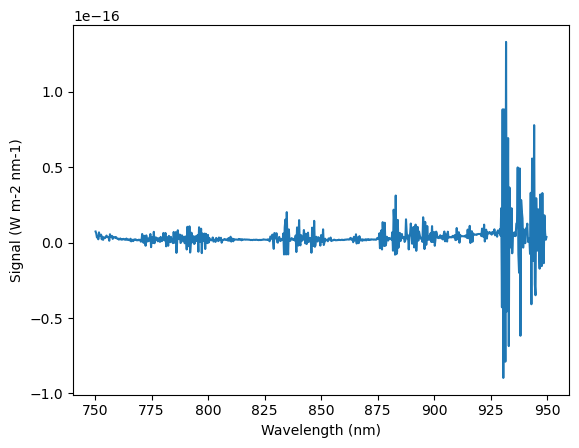

In [66]:
specplot('S20250928S0033_1D.fits',  wavelen=[750, 950])

In [67]:
# T1_nuc
t1nuc_files = dataselect.select_data(all_files,
                                      ['SPECT'],
                                      ['CAL'],
                                      dataselect.expr_parser('object=="T1_nuc" and ut_date=="2025-9-27"')
                                     )
t1nuc_files.extend(dataselect.select_data(all_files,
                                      ['SPECT'],
                                      ['CAL'],
                                      dataselect.expr_parser('object=="T1_nuc" and ut_date=="2025-9-28"')
                                     )
                   )
for gal in t1nuc_files:
    print(gal)

/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0047.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0048.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0054.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0055.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0058.fits
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0061.fits


In [68]:
reduce_t1nuc = reduce(t1nuc_files, inter=True)

All submitted files appear valid:
/Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0047.fits ... /Users/bryan.miller/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0061.fits, 6 files submitted.
RECIPE: reduceScience
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
         PRIMITIVE: addMDF
         -----------------
         .
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         -----------------------------

In [69]:
drdisplay('S20250928S0047_2D.fits')

All submitted files appear valid:
S20250928S0047_2D.fits
WARNING - No recipe can be found in gmos recipe libs.
WARNING - Searching primitives ...
Found 'display' as a primitive.
RECIPE: display
   PRIMITIVE: display
   ------------------
   .
reduce completed successfully.


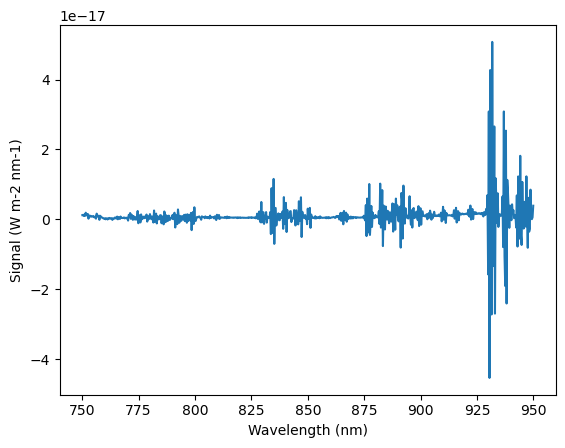

In [70]:
specplot('S20250928S0047_1D.fits',  wavelen=[750, 950])